## Búsqueda tipo Algoritmo 3 (Huang et al.) con cLAT completa vs podada

 - Usa branch-and-bound al estilo Matsui.
 - Usa cLAT en la parte de las sumas mod 2^n (LR: Splitting-Lookup-Recombination).
 - Compara cLAT completa y podada para muchas máscaras iniciales aleatorias
  y genera un pie chart con las categorías:
  * mismo trail y mismo Cw
  * mismo Cw pero trail distinto
  * podada encuentra algo mejor
  * podada encuentra algo peor
  * alguno de los dos no encuentra trail

### Importar librerias

In [1]:
import gzip
import pickle
import random
import math
from collections import Counter
from functools import lru_cache

import matplotlib.pyplot as plt

### Cargar la cLAT podada y la completa

In [2]:
# %%
# ==== CONFIGURA AQUÍ ====
PATH_CLAT_FULL   = "clat_speck.pkl.gz"
PATH_CLAT_PRUNED = "clat_speck_pruned.pkl.gz"

# número de rondas que vas a analizar
R = 5  # por ejemplo, 8 rondas de SPECK32

# número de máscaras iniciales aleatorias
NUM_TRIALS = 200

# tamaño de palabra (SPECK32 usa 16)
WORD_SIZE = 16


def load_pickle_maybe_gz(path):
    """Carga un pickle normal o gzip."""
    if path.endswith(".gz"):
        with gzip.open(path, "rb") as f:
            return pickle.load(f)
    else:
        with open(path, "rb") as f:
            return pickle.load(f)


clat_full_raw   = load_pickle_maybe_gz(PATH_CLAT_FULL)
clat_pruned_raw = load_pickle_maybe_gz(PATH_CLAT_PRUNED)
print("cLAT full type:", type(clat_full_raw))
print("cLAT pruned type:", type(clat_pruned_raw))


cLAT full type: <class 'dict'>
cLAT pruned type: <class 'dict'>


### Normalizar tu cLAT a un formato común

In [3]:
def normalize_clat(clat_raw):
    """
    Convierte clat_raw a:
        clat[v] -> list of (w, u, Cw)

    Intenta detectar automáticamente entre varios formatos típicos:
      1) list of (v, w, u, cw)
      2) dict[v][w][u] = cw
      3) dict[(v, w, u)] = cw
      4) dict[v] = list[(w, u, cw)]
      5) payload guardado por CLAT8.save():
         {
           "m": ...,
           "cLATu": {v:{b:{Cw:[u,...]}}},
           "cLATw": {v:{b:{Cw:[w,...]}}},
           ...
         }
      6) instancia de CLAT8 con atributos cLATu / cLATw
    """
    from collections import defaultdict

    clat = defaultdict(list)

    # ---------------------------
    # Caso 0: instancia de CLAT8
    # ---------------------------
    # (tanto la versión "full" como la podada comparten cLATu/cLATw)
    if hasattr(clat_raw, "cLATu") and hasattr(clat_raw, "cLATw"):
        cLATu = clat_raw.cLATu
        cLATw = clat_raw.cLATw

        # cLATu[v][b][Cw] = [u,...]
        # cLATw[v][b][Cw] = [w,...]
        for v, b_dict in cLATu.items():
            for b, cw_dict in b_dict.items():
                for cw, u_list in cw_dict.items():
                    w_list = cLATw[v][b][cw]
                    for u, w in zip(u_list, w_list):
                        clat[v].append((w, u, float(cw)))
        return dict(clat)

    # ---------------------------------
    # Caso 1: lista de tuplas (v, w, u, cw)
    # ---------------------------------
    if isinstance(clat_raw, list):
        for item in clat_raw:
            if len(item) != 4:
                raise ValueError("Lista de cLAT no parece de tuplas (v,w,u,cw)")
            v, w, u, cw = item
            clat[v].append((w, u, float(cw)))
        return dict(clat)

    # ---------------------------------
    # Casos tipo dict
    # ---------------------------------
    if isinstance(clat_raw, dict):

        # -----------------------------------------
        # Caso 5: payload de CLAT8.save() cargado
        # -----------------------------------------
        # Los scripts clat_speck32.py y clat_speck_pruned.py guardan
        # un dict con claves "m", "cLATu", "cLATw", "cLATmin", etc.
        if "cLATu" in clat_raw and "cLATw" in clat_raw:
            cLATu = clat_raw["cLATu"]
            cLATw = clat_raw["cLATw"]

            for v, b_dict in cLATu.items():
                for b, cw_dict in b_dict.items():
                    for cw, u_list in cw_dict.items():
                        w_list = cLATw[v][b][cw]
                        for u, w in zip(u_list, w_list):
                            clat[v].append((w, u, float(cw)))
            return dict(clat)

        # ---------------------------------
        # Resto de casos B/C/D originales
        # ---------------------------------
        items = list(clat_raw.items())
        if not items:
            return {}

        key0, val0 = items[0]

        # Caso 3: dict[(v, w, u)] = cw
        if isinstance(key0, tuple) and len(key0) == 3 and not isinstance(val0, (dict, list)):
            for (v, w, u), cw in items:
                clat[v].append((w, u, float(cw)))
            return dict(clat)

        # Caso 2 y 4: dict[v][w][u] = cw  ó  dict[v] = list[(w, u, cw)]
        if isinstance(val0, dict):
            sub_items = list(val0.items())

            # Caso 2: dict[v][w][u] = cw
            if sub_items and isinstance(sub_items[0][1], dict):
                for v, w_dict in clat_raw.items():
                    for w, u_dict in w_dict.items():
                        for u, cw in u_dict.items():
                            clat[v].append((w, u, float(cw)))
                return dict(clat)

            # Caso 4: dict[v] = list[(w, u, cw)]
            if sub_items and isinstance(sub_items[0][1], list):
                for v, triple_list in clat_raw.items():
                    for w, u, cw in triple_list:
                        clat[v].append((w, u, float(cw)))
                return dict(clat)

        raise TypeError("Formato de dict de cLAT no reconocido en normalize_clat().")

    raise TypeError("Tipo de cLAT no soportado en normalize_clat().")


In [4]:

clat_full   = normalize_clat(clat_full_raw)
clat_pruned = normalize_clat(clat_pruned_raw)

# estadísticas rápidas
print("Entradas distintas v en cLAT full  :", len(clat_full))
print("Entradas distintas v en cLAT podada:", len(clat_pruned))


Entradas distintas v en cLAT full  : 256
Entradas distintas v en cLAT podada: 256


In [5]:
clat_pruned

{0: [(0, 0, 8.0),
  (0, 1, 8.0),
  (1, 0, 8.0),
  (1, 1, 8.0),
  (2, 2, 8.0),
  (2, 3, 8.0),
  (3, 2, 8.0),
  (3, 3, 8.0),
  (4, 4, 8.0),
  (4, 5, 8.0),
  (5, 4, 8.0),
  (5, 5, 8.0),
  (6, 6, 8.0),
  (6, 7, 8.0),
  (7, 6, 8.0),
  (7, 7, 8.0),
  (8, 8, 8.0),
  (8, 9, 8.0),
  (9, 8, 8.0),
  (9, 9, 8.0),
  (10, 10, 8.0),
  (10, 11, 8.0),
  (11, 10, 8.0),
  (11, 11, 8.0),
  (12, 12, 8.0),
  (12, 13, 8.0),
  (13, 12, 8.0),
  (13, 13, 8.0),
  (14, 14, 8.0),
  (14, 15, 8.0),
  (15, 14, 8.0),
  (15, 15, 8.0),
  (16, 16, 8.0),
  (16, 17, 8.0),
  (17, 16, 8.0),
  (17, 17, 8.0),
  (18, 18, 8.0),
  (18, 19, 8.0),
  (19, 18, 8.0),
  (19, 19, 8.0),
  (20, 20, 8.0),
  (20, 21, 8.0),
  (21, 20, 8.0),
  (21, 21, 8.0),
  (22, 22, 8.0),
  (22, 23, 8.0),
  (23, 22, 8.0),
  (23, 23, 8.0),
  (24, 24, 8.0),
  (24, 25, 8.0),
  (25, 24, 8.0),
  (25, 25, 8.0),
  (26, 26, 8.0),
  (26, 27, 8.0),
  (27, 26, 8.0),
  (27, 27, 8.0),
  (28, 28, 8.0),
  (28, 29, 8.0),
  (29, 28, 8.0),
  (29, 29, 8.0),
  (30, 30, 8.0),


### LR: Splitting-Lookup-Recombination “tipo paper”

In [6]:
@lru_cache(maxsize=None)
def LR(v, clat):
    """
    Splitting-Lookup-Recombination "simplificado":
    dado un v (máscara de entrada de la suma), devuelve todas
    las tuplas (w, u, Cw) que conoces para ese v en la tabla.

    Si quieres implementar el esquema completo de splitting en subbloques,
    puedes sustituir esta función por la implementación detallada del paper.
    """
    return clat.get(v, [])


### Máscaras de estado y propagación por ronda

In [7]:
# %%
def ror(x, r, bits=WORD_SIZE):
    r %= bits
    return ((x >> r) | (x << (bits - r))) & ((1 << bits) - 1)


def rol(x, r, bits=WORD_SIZE):
    r %= bits
    return ((x << r) | (x >> (bits - r))) & ((1 << bits) - 1)


def speck_children_one_round(state, clat):
    """
    Implementa 1 ronda de SPECK32 a nivel de máscaras, usando cLAT en la suma.

    Entrada:
        state = (alpha, beta) máscaras antes de la ronda
        clat  = diccionario v -> [(w, u, Cw), ...], donde v = máscara de 'a'.

    Devuelve:
        lista de tuplas (next_state, Cw_round)
    """
    alpha, beta = state

    # 1) entrada a la suma: a = ROR(alpha, 7), b = beta
    v = ror(alpha, 7, WORD_SIZE)

    candidates = LR(v, clat)   # lista de (w, u, Cw) para esa máscara de 'a'
    children = []

    for w, u, cw in candidates:
        # 'w' debería ser la máscara asociada a la otra entrada 'b' (es decir, y)
        # y 'u' la máscara de salida de la suma
        # Comprobamos consistencia opcional: si quieres, puedes exigir w == beta.
        # Si tu cLAT fue generada condicionando el segundo input, elimina el chequeo.

        # Si quieres estrictamente w == beta, descomenta esto:
        # if w != beta:
        #     continue

        # 2) máscara después de la suma (antes de XOR con la llave)
        sum_out = u  # XOR con clave no afecta el peso ni cambia la máscara

        # 3) salida de la ronda:
        #    x' = sum_out
        #    y' = ROL(beta, 2) XOR x'
        x_next = sum_out
        y_next = rol(beta, 2, WORD_SIZE) ^ x_next

        children.append(((x_next, y_next), cw))

    return children


### Branch-and-bound tipo Matsui (Algoritmo 3)

In [8]:
class MatsuiSearcherAlg3:
    """
    Implementación tipo Algoritmo 3 (branch-and-bound) parametrizada
    por:
      - R: número de rondas
      - children_fn(round_idx, state, clat): genera (next_state, cw_round)
      - min_cw_per_round[i]: lower bound de la Cw en la ronda i

    Esto refleja:
      * Round-1 / Round-2: primeras llamadas con más poda por B_c^{r-1}, B_c^{r-2}
      * Round-r(i,x,y): llamadas recursivas para rondas intermedias
    """

    def __init__(self, R, clat, children_fn, min_cw_per_round=None):
        self.R = R
        self.clat = clat
        self.children_fn = children_fn
        self.min_cw_per_round = (
            list(min_cw_per_round) if min_cw_per_round is not None
            else [0.0] * R
        )
        self.best_cw = float("inf")
        self.best_path = None

    def lower_bound_remaining(self, round_idx):
        """Suma de mínimos desde round_idx hasta R-1."""
        return sum(self.min_cw_per_round[round_idx:])

    def search_from(self, start_state):
        """Punto de entrada (línea 1 del Algoritmo 3)."""
        self.best_cw = float("inf")
        self.best_path = None
        self._dfs(round_idx=0,
                  state=start_state,
                  cw_so_far=0.0,
                  path=[start_state])
        return self.best_cw, self.best_path

    def _dfs(self, round_idx, state, cw_so_far, path):
        # Caso base: ya hemos hecho R rondas → trail completo
        if round_idx == self.R:
            if cw_so_far < self.best_cw:
                self.best_cw = cw_so_far
                self.best_path = list(path)
            return

        # Poda tipo Matsui / Huang:
        bound = cw_so_far + self.lower_bound_remaining(round_idx)
        if bound >= self.best_cw:
            return

        # Generamos hijos (esta función encapsula LR + estructura del cifrador)
        children = self.children_fn(round_idx, state, self.clat)

        # Si quieres imitar que en las primeras rondas se exigen pesos crecientes,
        # puedes ordenar por cw_round antes de explorar.
        children = sorted(children, key=lambda child: child[1])

        for next_state, cw_round in children:
            self._dfs(
                round_idx + 1,
                next_state,
                cw_so_far + cw_round,
                path + [next_state],
            )


### Leer las mascaras

In [9]:
def load_mask_pairs(path):
    """
    Lee un archivo tipo:
        0xe8d9    0x041d
        0xce2a    0x2611
    y devuelve [(u16, v16), ...].
    """
    pairs = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            u_hex, v_hex = parts[0], parts[1]
            u = int(u_hex, 16)
            v = int(v_hex, 16)
            pairs.append((u, v))
    return pairs

mask_pairs_1234 = load_mask_pairs("pares_1234_abcd.txt")
mask_pairs_0006 = load_mask_pairs("pares_0006_0000.txt")

len(mask_pairs_1234), len(mask_pairs_0006)


(1000, 1000)

### Wrapper para Matsui

In [10]:
def matsui_search_for_pair(clat, R, u0, v0, children_fn, min_cw_per_round=None):
    """
    Ejecuta MatsuiSearcherAlg3 para un par inicial (u0, v0).

    clat: cLAT (full o podada) que usa children_fn
    R:   número de rondas a explorar
    u0, v0: máscaras iniciales
    children_fn: función de expansión por ronda
    min_cw_per_round: lista de lower bounds por ronda (opcional)
    """
    start_state = (u0, v0)   # si tu state es otra cosa, ajústalo aquí

    searcher = MatsuiSearcherAlg3(
        R=R,
        clat=clat,
        children_fn=children_fn,
        min_cw_per_round=min_cw_per_round,
    )

    best_cw, best_path = searcher.search_from(start_state)
    return best_cw, best_path


In [11]:
def eval_pairs_with_matsui(clat, mask_pairs, R, children_fn, min_cw_per_round=None):
    """
    Aplica MatsuiSearcherAlg3 a cada (u, v) en mask_pairs.

    Retorna:
      - lista de mejores Cw por par
      - lista de mejores caminos (paths) por par
    """
    cws = []
    paths = []

    for (u, v) in mask_pairs:
        best_cw, best_path = matsui_search_for_pair(
            clat=clat,
            R=R,
            u0=u,
            v0=v,
            children_fn=children_fn,
            min_cw_per_round=min_cw_per_round,
        )
        cws.append(best_cw)
        paths.append(best_path)

    return cws, paths


In [12]:
def children_fn(round_idx, state, clat):
    """
    state: (u, v) actual
    clat:  dict normalizado: clat[v] -> list of (w, u_next, cw_round)
    """
    u, v = state
    children = []

    # Para el v actual, miro todas las posibles transiciones (w, u_next, cw_round)
    for (w, u_next, cw_round) in clat.get(v, []):
        next_state = (u_next, w)   # nuevo (u, v) para la siguiente ronda
        children.append((next_state, cw_round))

    return children


In [13]:
R = 5  # o las rondas que quieras explorar con Matsui

# Si tienes lower bounds por ronda, pásalos aquí. Si no, déjalo como None.
min_cw_per_round = None

# ---------- cLAT FULL ----------
cws_1234_full_matsui, paths_1234_full_matsui = eval_pairs_with_matsui(
    clat=clat_full,
    mask_pairs=mask_pairs_1234,
    R=R,
    children_fn=children_fn,
    min_cw_per_round=min_cw_per_round,
)

cws_0006_full_matsui, paths_0006_full_matsui = eval_pairs_with_matsui(
    clat=clat_full,
    mask_pairs=mask_pairs_0006,
    R=R,
    children_fn=children_fn,
    min_cw_per_round=min_cw_per_round,
)

# ---------- cLAT PODADA ----------
cws_1234_pruned_matsui, paths_1234_pruned_matsui = eval_pairs_with_matsui(
    clat=clat_pruned,
    mask_pairs=mask_pairs_1234,
    R=R,
    children_fn=children_fn,
    min_cw_per_round=min_cw_per_round,
)

cws_0006_pruned_matsui, paths_0006_pruned_matsui = eval_pairs_with_matsui(
    clat=clat_pruned,
    mask_pairs=mask_pairs_0006,
    R=R,
    children_fn=children_fn,
    min_cw_per_round=min_cw_per_round,
)


In [14]:
from collections import Counter
import math

def bucketize_cws_auto(cws):
    """
    Crea buckets a partir de los valores únicos de Cw.

    - None o ±inf → 'Non-valid'
    - Cada valor de Cw válido se convierte en un bucket con su propio label (str).
    """
    buckets = Counter()

    for cw in cws:
        if cw is None or (isinstance(cw, float) and math.isinf(cw)):
            buckets["Non-valid"] += 1
        else:
            # label del bucket = el propio valor de Cw
            label = f"{cw:g}"   # '0', '-17', '-34', '-51', etc.
            buckets[label] += 1

    return buckets

b_1234_full   = bucketize_cws_auto(cws_1234_full_matsui)
b_1234_pruned = bucketize_cws_auto(cws_1234_pruned_matsui)

b_0006_full   = bucketize_cws_auto(cws_0006_full_matsui)
b_0006_pruned = bucketize_cws_auto(cws_0006_pruned_matsui)


In [15]:
import matplotlib.pyplot as plt
import numpy as np

def plot_pie_from_buckets(buckets, title):
    labels = list(buckets.keys())
    sizes  = [buckets[l] for l in labels]

    fig, ax = plt.subplots()

    wedges, texts, autotexts = ax.pie(
        sizes,
        autopct='%1.1f%%',
        startangle=90,
        pctdistance=0.3,
    )

    # labels con flechita hacia afuera
    for i, w in enumerate(wedges):
        ang = 0.5 * (w.theta1 + w.theta2)
        x = np.cos(np.deg2rad(ang))
        y = np.sin(np.deg2rad(ang))

        xy = (0.9 * x, 0.9 * y)
        xytext = (1.4 * x, 1.4 * y)

        ax.annotate(
            labels[i],
            xy=xy,
            xytext=xytext,
            arrowprops=dict(arrowstyle='-', linewidth=1),
            ha='center',
            va='center'
        )

    ax.set_title(title, pad=20)
    ax.axis('equal')
    plt.show()


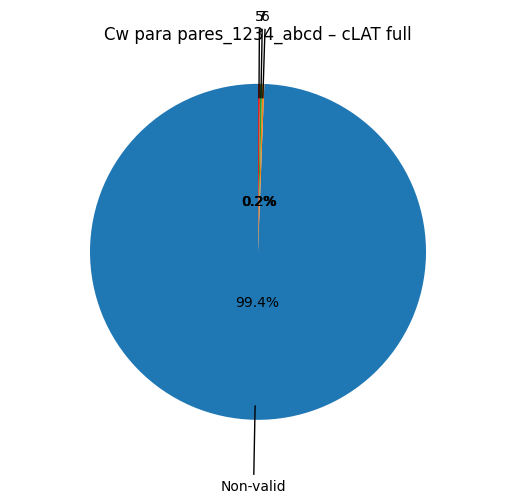

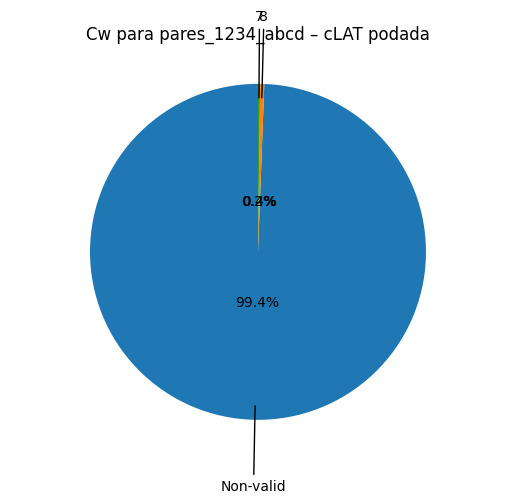

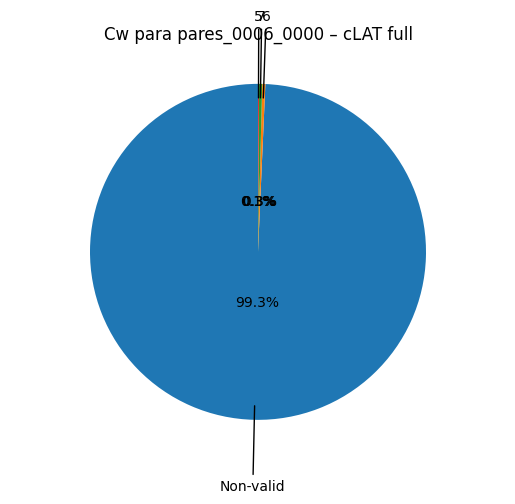

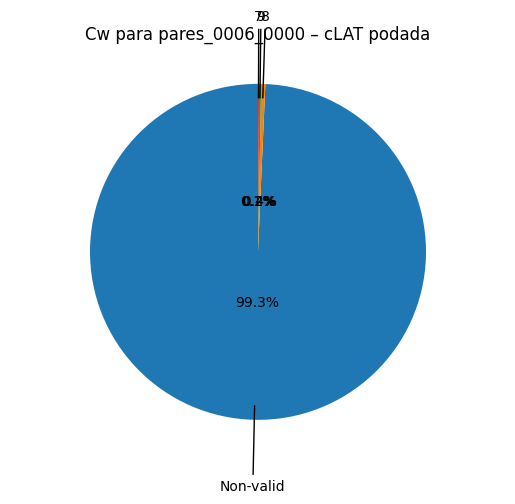

In [16]:
# Máscaras pares_1234_abcd.txt
plot_pie_from_buckets(b_1234_full,   "Cw para pares_1234_abcd – cLAT full")
plot_pie_from_buckets(b_1234_pruned, "Cw para pares_1234_abcd – cLAT podada")

# Máscaras pares_0006_0000.txt
plot_pie_from_buckets(b_0006_full,   "Cw para pares_0006_0000 – cLAT full")
plot_pie_from_buckets(b_0006_pruned, "Cw para pares_0006_0000 – cLAT podada")


In [17]:
b_1234_full

Counter({'Non-valid': 994, '6': 2, '7': 2, '5': 2})

In [18]:
b_1234_pruned

Counter({'Non-valid': 994, '8': 4, '7': 2})

In [19]:
b_0006_full

Counter({'Non-valid': 993, '6': 3, '7': 3, '5': 1})

In [20]:
b_0006_pruned

Counter({'Non-valid': 993, '8': 4, '9': 2, '7': 1})